# 2장 3강: 코호트 기반 리텐션 분석과 세그멘테이션 — 실습문제

## 실습 목표

- 분석 목적에 맞는 코호트 기준을 설정할 수 있다.
- 첫 유효 기능 사용 월을 기준으로 월간 코호트를 만들 수 있다.
- 코호트별 N개월 리텐션 테이블과 히트맵을 생성할 수 있다.
- 코호트와 세그먼트를 교차하여 그룹별 유지 패턴을 비교할 수 있다.
- 리텐션 차이를 근거로 개선 대상을 찾고 추가 분석 방향을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

Ravenstack은 구독형 B2B SaaS입니다. 이번 실습의 분석 질문은 다음과 같습니다.

> 제품 기능을 처음 사용한 구독이 이후 달에도 다시 기능을 사용하는가?

따라서 코호트 기준은 가입일이나 구독 시작일이 아니라 **첫 유효 기능 사용 월**로 설정합니다.

이번 실습에서 유효 기능 사용은 다음 조건을 모두 만족하는 기록입니다.

- `usage_date >= start_date`
- 종료일이 없거나 `usage_date <= end_date`

> 이번 실습의 월간 N개월 리텐션은 첫 유효 기능 사용 월로부터 정확히 N개월 뒤에 다시 기능을 사용한 구독의 비율입니다.

> 풀이 데이터: 이 폴더의 `data/` CSV. RavenStack은 River @ Rivalytics의 합성 교육용 데이터다. 실제 사업 성과로 일반화하지 않는다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 두 CSV 파일을 각각 `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치 개수를 확인하세요.
5. `start_date`, `end_date`, `usage_date`를 날짜형으로 변환하세요.
6. 기능 사용 데이터와 구독 데이터를 `subscription_id`로 결합하여 `usage_with_sub`을 만드세요.
7. 구독 시작 전 사용 기록과 구독 종료 후 사용 기록의 개수를 확인하세요.
8. 유효 기능 사용 조건을 적용한 `valid_usage`를 만드세요.

In [1]:
from pathlib import Path
import pandas as pd
DATA_DIR = Path('data')

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager
if 'Malgun Gothic' in {f.name for f in font_manager.fontManager.ttflist}:
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams.update({'axes.unicode_minus': False, 'figure.figsize': (8,4), 'font.size': 11})
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 30)
def show_rates(frame):
    display(frame.style.format({c: '{:.2%}' for c in frame.columns if 'rate' in str(c) or 'conversion' in str(c)}, na_rep='—'))
def bars(series, title, ylabel, percent=False):
    ax = (series * (100 if percent else 1)).plot.bar(color='#32689b', rot=0)
    ax.set(title=title, ylabel=ylabel, xlabel='')
    ax.set_ylim(bottom=0)
    plt.tight_layout(); plt.show()
def make_funnel(counts, labels):
    f = pd.DataFrame({'count': counts}, index=labels)
    prev = f['count'].shift().replace(0, np.nan)
    f['conversion_rate'] = f['count'] / prev
    f['drop_rate'] = 1 - f.conversion_rate
    f['drop_count'] = f['count'].shift() - f['count']
    return f

subscriptions = pd.read_csv(DATA_DIR / 'ravenstack_subscriptions.csv')
feature_usage = pd.read_csv(DATA_DIR / 'ravenstack_feature_usage.csv')
tables = {'subscriptions':subscriptions,'feature_usage':feature_usage}
for name, df in tables.items():
    for col in df.columns:
        if col.endswith('_date') or col in ['submitted_at', 'closed_at']:
            df[col] = pd.to_datetime(df[col], errors='raise')
    print(name, df.shape)
    display(df.head())
    display(pd.DataFrame({'dtype':df.dtypes.astype(str), 'missing':df.isna().sum()}))
if 'subscriptions' in tables:
    assert subscriptions.subscription_id.is_unique
    display(subscriptions.mrr_amount.describe())
    display(subscriptions.plan_tier.value_counts())
if 'feature_usage' in tables:
    print('usage_id 중복:', feature_usage.usage_id.duplicated().sum())
    print('구독 수 / 이벤트 행 수:', subscriptions.subscription_id.nunique(), len(feature_usage))
    display(feature_usage.feature_name.value_counts())
    display(feature_usage.usage_count.describe())
    assert feature_usage.subscription_id.isin(subscriptions.subscription_id).all()

usage_with_sub = feature_usage.merge(subscriptions, on='subscription_id', validate='many_to_one')
before = usage_with_sub.usage_date < usage_with_sub.start_date
after = usage_with_sub.end_date.notna() & (usage_with_sub.usage_date > usage_with_sub.end_date)
print('시작 전:', before.sum(), '종료 후:', after.sum())
valid_usage = usage_with_sub.loc[~before & ~after].copy()
analysis_end = feature_usage.usage_date.max()
print('관찰 종료:', analysis_end, '(이 날짜까지 로그가 완전하다고 가정)')

subscriptions (5000, 14)


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,False,False,monthly,True


,dtype,missing
subscription_id,object,0
account_id,object,0
start_date,datetime64[ns],0
end_date,datetime64[ns],4514
plan_tier,object,0
seats,int64,0
mrr_amount,int64,0
arr_amount,int64,0
is_trial,bool,0
upgrade_flag,bool,0


feature_usage (25000, 8)


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


...

plan_tier
Enterprise    1723
Pro           1675
Basic         1602
Name: count, dtype: int64

usage_id 중복: 21
구독 수 / 이벤트 행 수: 5000 25000


feature_name
feature_32    659
feature_12    659
feature_6     655
feature_17    651
feature_34    650
             ... 
feature_19    589
feature_18    588
feature_35    587
feature_5     577
feature_23    563
Name: count, Length: 40, dtype: int64

count    25000.000000
mean        10.021000
std          3.143729
min          0.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         26.000000
Name: usage_count, dtype: float64

시작 전: 19142 종료 후: 290
관찰 종료: 2024-12-31 00:00:00 (이 날짜까지 로그가 완전하다고 가정)


---

## 필수 1. 월별 코호트 리텐션 테이블 만들기

### 문제 1-1. 첫 기능 사용 이후에도 다시 제품을 사용하는가?

#### 문제 설명

각 구독의 첫 유효 기능 사용 월을 코호트로 설정하고, 이후 월별로 다시 기능을 사용한 구독의 비율을 계산하세요.

이번 문제에서는 2024년 1월부터 6월까지 시작한 코호트와 `Month 0`부터 `Month 6`까지의 리텐션을 확인합니다.

#### 요구사항

1. `valid_usage`에 기능 사용 월을 나타내는 `activity_month`를 만드세요.
2. 구독별 첫 `activity_month`를 구해 `cohort_month`로 추가하세요.
3. `activity_month - cohort_month`를 개월 수로 계산하여 `month_index`를 만드세요.
4. 코호트별 최초 구독 수를 `cohort_sizes`로 계산하세요.
5. `cohort_month`와 `month_index`별 고유 구독 수를 집계하세요.
6. 고유 구독 수를 `cohort_sizes`로 나누어 `retention_table`을 만드세요.
7. 2024년 1월~6월 코호트와 Month 0~6을 선택하여 백분율 표로 출력하세요.
8. 선택한 리텐션 테이블을 히트맵으로 시각화하세요.
9. 1월~6월 코호트 중 Month 1 리텐션이 가장 높은 코호트와 가장 낮은 코호트를 찾으세요.

#### 해석 질문

**Q1.** 이번 분석에서 첫 기능 사용 월을 코호트 기준으로 선택한 이유는 무엇인가요?  
**Q2.** Month 0 리텐션이 모두 100%인 이유는 무엇인가요?  
**Q3.** Month 1 리텐션이 가장 높은 코호트와 가장 낮은 코호트는 어디인가요?  
**Q4.** N개월 리텐션이 앞선 달보다 높아질 수도 있나요?

#### 제출 결과

- 코호트 및 `month_index` 생성 코드
- 월별 리텐션 테이블
- 리텐션 히트맵
- Month 1 리텐션 비교
- Q1~Q4 답변

2024-01     73
2024-02     89
2024-03    107
2024-04    106
2024-05    137
2024-06    150
Freq: M, Name: 최초 구독 수, dtype: int64

month_index,0,1,2,3,4,5,6
2024-01,100.00%,15.07%,16.44%,19.18%,20.55%,16.44%,19.18%
2024-02,100.00%,21.35%,16.85%,15.73%,7.87%,23.60%,28.09%
2024-03,100.00%,22.43%,22.43%,20.56%,19.63%,10.28%,21.50%
2024-04,100.00%,17.92%,27.36%,19.81%,19.81%,16.04%,15.09%
2024-05,100.00%,18.25%,19.71%,16.79%,21.17%,19.71%,15.33%
2024-06,100.00%,28.00%,12.00%,16.00%,20.00%,15.33%,21.33%


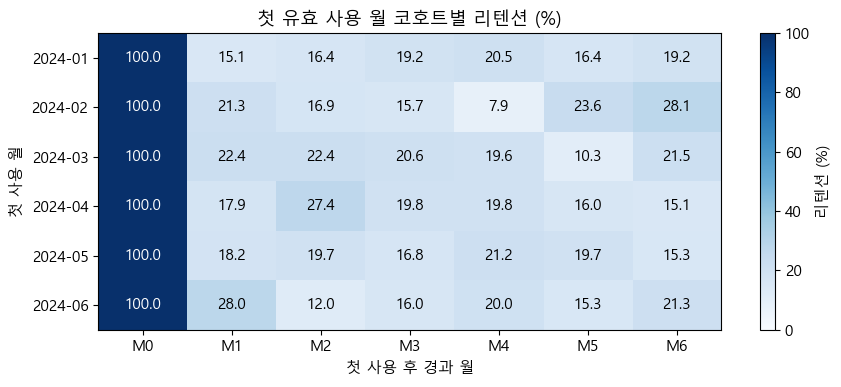

In [2]:
valid_usage['activity_month'] = valid_usage.usage_date.dt.to_period('M')
valid_usage['cohort_month'] = valid_usage.groupby('subscription_id').activity_month.transform('min')
valid_usage['month_index'] = valid_usage.activity_month.astype('int64') - valid_usage.cohort_month.astype('int64')
cohort_sizes = valid_usage.groupby('cohort_month').subscription_id.nunique()
cohort_counts = valid_usage.groupby(['cohort_month','month_index']).subscription_id.nunique().unstack(fill_value=0)
selected_cohorts = pd.period_range('2024-01','2024-06',freq='M')
retention_table = cohort_counts.div(cohort_sizes,axis=0).reindex(index=selected_cohorts,columns=range(7))
for cohort in retention_table.index:
    for month in retention_table.columns:
        if (cohort+month).end_time.normalize() > analysis_end:
            retention_table.loc[cohort,month] = np.nan
display(cohort_sizes.reindex(selected_cohorts).rename('최초 구독 수'))
display(retention_table.style.format('{:.2%}',na_rep='관찰 불가'))
fig,ax=plt.subplots(figsize=(9,4))
im=ax.imshow(retention_table*100,vmin=0,vmax=100,cmap='Blues',aspect='auto')
ax.set(xticks=range(7),xticklabels=[f'M{x}' for x in range(7)],yticks=range(6),yticklabels=selected_cohorts.astype(str),title='첫 유효 사용 월 코호트별 리텐션 (%)',xlabel='첫 사용 후 경과 월',ylabel='첫 사용 월')
for i in range(6):
    for j in range(7):
        v=retention_table.iloc[i,j]*100
        ax.text(j,i,'—' if pd.isna(v) else f'{v:.1f}',ha='center',va='center',color='white' if v>55 else 'black')
fig.colorbar(im,ax=ax,label='리텐션 (%)'); plt.tight_layout(); plt.show()

### 필수 1 답변
- **Q1.** 기능을 실제로 경험한 뒤 재사용하는지를 묻기 때문에 첫 유효 기능 사용 월을 기준으로 삼는다.
- **Q2.** 최초 사용 구독이 바로 분모이므로 M0는 100%다.
- **Q3.** M1 최고는 2024-06 (28.00%), 최저는 2024-01 (15.07%)다.
- **Q4.** 가능하다. 해당 월에 돌아온 구독을 세므로 전월 미사용자가 다시 포함된다. 생존율과 달리 단조 감소할 필요가 없다.

---

## 필수 2. 요금제별 Month 1 리텐션 비교하기

### 문제 2-1. 어떤 요금제의 초기 유지율이 상대적으로 낮은가?

#### 문제 설명

2024년 1월부터 6월까지 첫 기능 사용을 시작한 구독을 대상으로 요금제별 Month 1 리텐션을 비교하세요.

이 문제는 **코호트 기준과 속성 기반 세그먼트인 `plan_tier`를 교차하여 분석**하는 문제입니다.

#### 요구사항

1. 구독별 `cohort_month`, `plan_tier`를 한 행으로 정리한 `cohort_base`를 만드세요.
2. 2024년 1월~6월 코호트만 `selected_base`에 저장하세요.
3. 요금제별 코호트 구독 수를 계산하세요.
4. `month_index == 1`인 기록을 이용해 요금제별 Month 1 재사용 구독 수를 계산하세요.
5. 두 값을 나누어 `plan_retention`을 만드세요.
6. Month 1 리텐션이 낮은 순서로 정렬하고 백분율로 출력하세요.
7. 요금제별 Month 1 리텐션을 막대그래프로 시각화하세요.
8. 가장 낮은 요금제를 찾아 개선 방향과 추가 확인 데이터를 제안하세요.

#### 해석 질문

**Q1.** 이 분석에서 `plan_tier`는 어떤 세그멘테이션 기준인가요?  
**Q2.** Month 1 리텐션이 가장 낮은 요금제는 무엇인가요?  
**Q3.** 전체 리텐션만 보는 것보다 요금제별로 나누어 보는 것이 유용한 이유는 무엇인가요?  
**Q4.** 요금제별 차이만으로 낮은 리텐션의 원인을 확정할 수 있나요?

#### 제출 결과

- `cohort_base`와 `selected_base`
- `plan_retention` 결과
- 요금제별 리텐션 그래프
- 개선 방향과 추가 확인 데이터
- Q1~Q4 답변

,cohort_subscriptions,reused,retention_rate
plan_tier,,,
Basic,223,42,18.83%
Pro,219,48,21.92%
Enterprise,220,50,22.73%


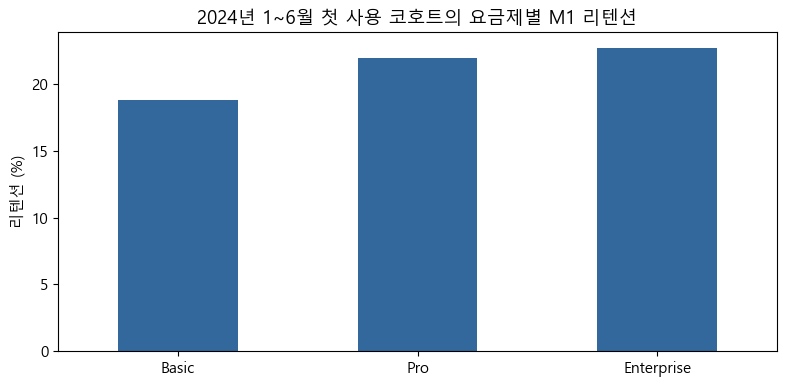

In [3]:
cohort_base = valid_usage[['subscription_id','cohort_month','plan_tier','billing_frequency']].drop_duplicates('subscription_id')
selected_base = cohort_base.loc[cohort_base.cohort_month.isin(selected_cohorts)].copy()
m1_ids = set(valid_usage.loc[valid_usage.month_index.eq(1),'subscription_id'])
selected_base['reused_m1'] = selected_base.subscription_id.isin(m1_ids)
plan_retention = selected_base.groupby('plan_tier').agg(cohort_subscriptions=('subscription_id','nunique'), reused=('reused_m1','sum'), retention_rate=('reused_m1','mean')).sort_values('retention_rate')
show_rates(plan_retention)
bars(plan_retention.retention_rate,'2024년 1~6월 첫 사용 코호트의 요금제별 M1 리텐션','리텐션 (%)',True)

### 필수 2 답변
- **Q1.** 구독의 상품 속성에 따른 세그먼트다.
- **Q2.** Basic (18.83%)다.
- **Q3.** 같은 첫 사용 기준에서 상품별 초기 유지 문제를 찾아 온보딩 개선 대상을 정할 수 있다. 합산 지표는 월별 코호트 구성 차이의 영향을 받는다.
- **Q4.** 확정할 수 없다. 기능 오류·첫 사용 깊이·고객 규모·코호트 구성을 확인하고 초기 성공 경험을 돕는 안내를 검증한다.

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 코호트·결제 주기별 Month 1~3 리텐션 비교하기

#### 문제 설명

2024년 1월부터 6월까지의 첫 유효 기능 사용 월 코호트를 대상으로, 월간 결제 구독과 연간 결제 구독의 Month 1~3 리텐션을 비교하세요. 시간이 지나면서 유지율이 어떻게 변하는지 확인하고 개선 방향을 제안하세요.

> 필수 1의 월별 코호트 분석과 필수 2의 세그먼트별 비교 절차를 활용하는 문제입니다.

#### 요구사항

1. 구독별 cohort_month, billing_frequency를 한 행으로 정리하세요.
2. 2024년 1월~6월 코호트만 선택하고, 각 코호트의 Month 3까지 관찰 가능한지 확인하세요. 아직 관찰하지 못한 월은 리텐션을 0으로 처리하지 마세요.
3. 코호트·결제 주기별 최초 구독 수와 Month 1·2·3 각각의 고유 재사용 구독 수를 계산하세요. 같은 구독이 같은 달에 여러 번 사용해도 한 번만 세세요.
4. 다음 식으로 billing_retention을 만드세요.
- 리텐션 = 해당 경과 월의 고유 재사용 구독 수 ÷ 해당 코호트·결제 주기의 최초 구독 수
- Month 1~3 모두 같은 최초 구독 수를 분모로 사용하세요.
- 이전 달에 사용하지 않았어도 해당 달에 다시 사용했다면 포함하세요.
5. 행은 코호트·결제 주기, 열은 Month 1~3인 리텐션 표를 만들고 백분율로 출력하세요.
6. 코호트별로 월간·연간 결제 구독의 Month 1~3 리텐션을 비교하는 선그래프를 그리세요.
7. 각 코호트에서 두 결제 주기의 Month 1 리텐션 차이와, 각 결제 주기의 Month 1→2 및 Month 2→3 변화폭을 %p로 계산하세요. 감소·유지·회복 등의 패턴을 실제 결과에 맞게 해석하세요.
8. 우선 점검할 코호트·결제 주기 조합을 선택하고, 수치 근거·가능한 원인 가설·개선 방향·추가 확인 데이터를 제안하세요. 원인 가설을 확인된 사실처럼 단정하지 마세요.

#### 해석 질문

**Q1.** 각 코호트에서 Month 1 리텐션이 더 낮은 결제 주기는 무엇이며, 두 결제 주기의 차이는 몇 %p인가요?

**Q2.** 코호트·결제 주기별 Month 1→2 및 Month 2→3 변화폭은 몇 %p이며, 어떤 유지 패턴이 나타나나요?

**Q3.** 우선 점검할 코호트·결제 주기는 무엇인가요? 수치 근거와 가능한 원인 가설, 개선 방향을 설명하세요.

**Q4.** 이 결과만으로 결제 주기가 낮은 리텐션의 원인이라고 판단할 수 있나요? 추가로 어떤 데이터를 확인해야 하나요?

#### 제출 결과

- 코호트·결제 주기별 최초 구독 수와 Month 1~3 고유 재사용 구독 수
- billing_retention 표와 리텐션 선그래프
- 결제 주기 간 차이와 경과 월별 변화폭(%p)
- 시간 경과에 따른 유지 패턴 해석
- 우선 점검 대상·원인 가설·개선 방향·추가 확인 데이터
- Q1~Q4 답변

cohort_month  billing_frequency
2024-01       annual               46
              monthly              27
2024-02       annual               39
              monthly              50
2024-03       annual               55
              monthly              52
2024-04       annual               49
              monthly              57
2024-05       annual               68
              monthly              69
2024-06       annual               67
              monthly              83
Name: 최초 구독 수, dtype: int64

month_index                        1     2     3
cohort_month billing_frequency                  
2024-01      annual              6.0   7.0  10.0
             monthly             5.0   5.0   4.0
2024-02      annual             10.0   5.0   4.0
             monthly             9.0  10.0  10.0
2024-03      annual             11.0  11.0  11.0
             monthly            13.0  13.0  11.0
2024-04      annual              8.0  13.0   8.0
             monthly            11.0  16.0  13.0
2024-05      annual             15.0  14.0  11.0
             monthly            10.0  13.0  12.0
2024-06      annual             20.0   9.0  13.0
             monthly            22.0   9.0  11.0

cohort_month
2024-01    5.475040
2024-02   -7.641026
2024-03    5.000000
2024-04    2.971715
2024-05   -7.566070
2024-06   -3.344722
Freq: M, Name: M1 monthly−annual (%p), dtype: float64

M1→M2 (%p)  M2→M3 (%p)
cohort_month billing_frequency                        
2024-01      annual                   2.17        6.52
             monthly                  0.00       -3.70
2024-02      annual                 -12.82       -2.56
             monthly                  2.00        0.00
2024-03      annual                   0.00        0.00
             monthly                  0.00       -3.85
2024-04      annual                  10.20      -10.20
             monthly                  8.77       -5.26
2024-05      annual                  -1.47       -4.41
             monthly                  4.35       -1.45
2024-06      annual                 -16.42        5.97
             monthly                -15.66        2.41

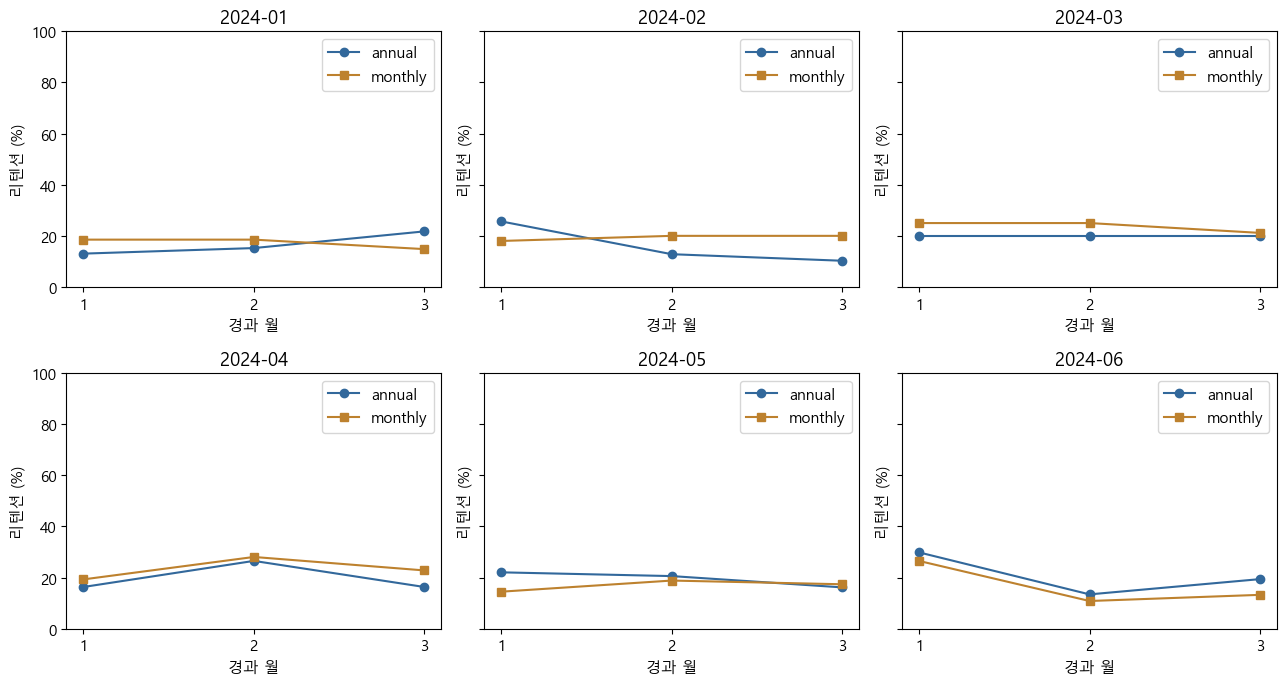

In [4]:
billing_sizes = selected_base.groupby(['cohort_month','billing_frequency']).subscription_id.nunique()
billing_counts = valid_usage.loc[valid_usage.cohort_month.isin(selected_cohorts) & valid_usage.month_index.isin([1,2,3])].groupby(['cohort_month','billing_frequency','month_index']).subscription_id.nunique().unstack(fill_value=0).reindex(index=billing_sizes.index,columns=[1,2,3],fill_value=0).astype(float)
for cohort,billing in billing_counts.index:
    for month in [1,2,3]:
        if (cohort+month).end_time.normalize() > analysis_end:
            billing_counts.loc[(cohort,billing),month] = np.nan
billing_retention = billing_counts.div(billing_sizes,axis=0)
display(billing_sizes.rename('최초 구독 수')); display(billing_counts)
display(billing_retention.style.format('{:.2%}',na_rep='관찰 불가'))
m1_gap = (billing_retention[1].unstack()['monthly']-billing_retention[1].unstack()['annual'])*100
changes = pd.DataFrame({'M1→M2 (%p)':(billing_retention[2]-billing_retention[1])*100,'M2→M3 (%p)':(billing_retention[3]-billing_retention[2])*100})
display(m1_gap.rename('M1 monthly−annual (%p)')); display(changes.round(2))
fig,axes=plt.subplots(2,3,figsize=(13,7),sharey=True)
for ax,cohort in zip(axes.flat,selected_cohorts):
    for billing,color,marker in [('annual','#32689b','o'),('monthly','#bd812e','s')]:
        ax.plot([1,2,3],billing_retention.loc[(cohort,billing)]*100,label=billing,color=color,marker=marker)
    ax.set(title=str(cohort),xticks=[1,2,3],xlabel='경과 월',ylabel='리텐션 (%)',ylim=(0,100)); ax.legend()
plt.tight_layout(); plt.show()

### 과제 1 답변
- **Q1.** M1의 monthly−annual 차이(%p)는 2024-01: 5.48, 2024-02: -7.64, 2024-03: 5.00, 2024-04: 2.97, 2024-05: -7.57, 2024-06: -3.34이다. 음수인 달은 monthly, 양수인 달은 annual이 낮다.
- **Q2.** 위 변화폭 표의 각 행이 Q2의 계산 결과다. 양수는 회복, 음수는 감소, 0은 유지다. 총 8개 증가 구간과 11개 감소 구간이 있어 일률적인 감소로 해석하지 않는다.
- **Q3.** M1이 가장 낮은 2024년 1월·annual (13.04%)를 우선 점검한다. 초기 가치 경험이 약하다는 가설하에 첫 달 사용 가이드를 개선한다. 작은 코호트는 소수 구독에 의해 비율이 크게 변하므로 분모도 함께 본다.
- **Q4.** 결제 주기 자체의 인과 효과는 아니다. 가입 캠페인, 요금제, 오류, 사용 횟수와 고객 규모를 확인하고 같은 코호트 내 안내 실험으로 검증한다.

---

## 실습 마무리

아래 질문에 답하세요.

1. 이번 분석에서는 어떤 행동을 코호트의 출발점으로 사용했나요?
2. 월간 N개월 리텐션은 어떻게 계산했나요?
3. 코호트와 세그먼트를 함께 분석하면 어떤 장점이 있나요?
4. 어떤 세그먼트의 Month 1 리텐션이 상대적으로 낮았나요?
5. 리텐션 차이와 실제 원인을 왜 구분해야 하나요?

### 마무리 답변
1. 첫 유효 기능 사용 월이 출발점이다.
2. N개월째 고유 재사용 구독 수를 최초 코호트 크기로 나눴다.
3. 같은 시작 시점에서 속성별 유지 패턴을 비교할 수 있다.
4. 위 요금제·코호트·결제 주기 표의 최저 M1 집단을 확인했다.
5. 관찰 비교에는 고객 구성 등의 교란이 있어 원인 가설과 구분해야 한다.